In [22]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

def plot_histogram(data):
    plt.figure(figsize=(12,8))
    plt.hist(data,bins=250)
    plt.show();

def replace_dataset(input_file, output_file, key, new_key, process_fn):
    assert input_file!=output_file
    with h5py.File(input_file, "r") as f_in, h5py.File(output_file, "w") as f_out:
        for name in f_in:
            f_in.copy(name, f_out)
        print(f"All available keys: {list(f_in.keys())}")
        data = f_in[key][:]

        plot_histogram(data[:].flatten())
        
        new_data = process_fn(data)
        # delete old dataset and write new one
        del f_out[key]
        f_out.create_dataset(new_key, data=new_data)

        plot_histogram(new_data[:].flatten())
        

def quantize(data):
    _min=-3.2
    _max=3.2
    _range=_max-_min
    quant_data=data
    quant_data = ((quant_data - _min)/ _range) 
    quant_data = (quant_data * 255.0) - 128.0
    quant_data = np.round(quant_data)
    quant_data = np.clip(quant_data,-128.0, 127.0)
    return quant_data.astype(np.int8)

All available keys: ['all_IQ', 'all_labels']


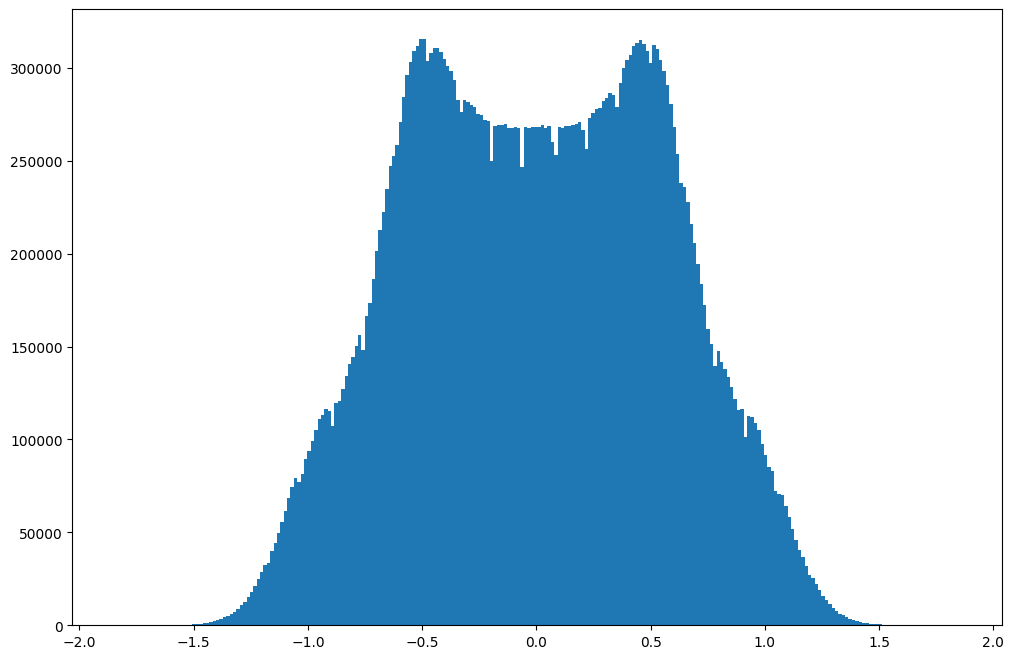

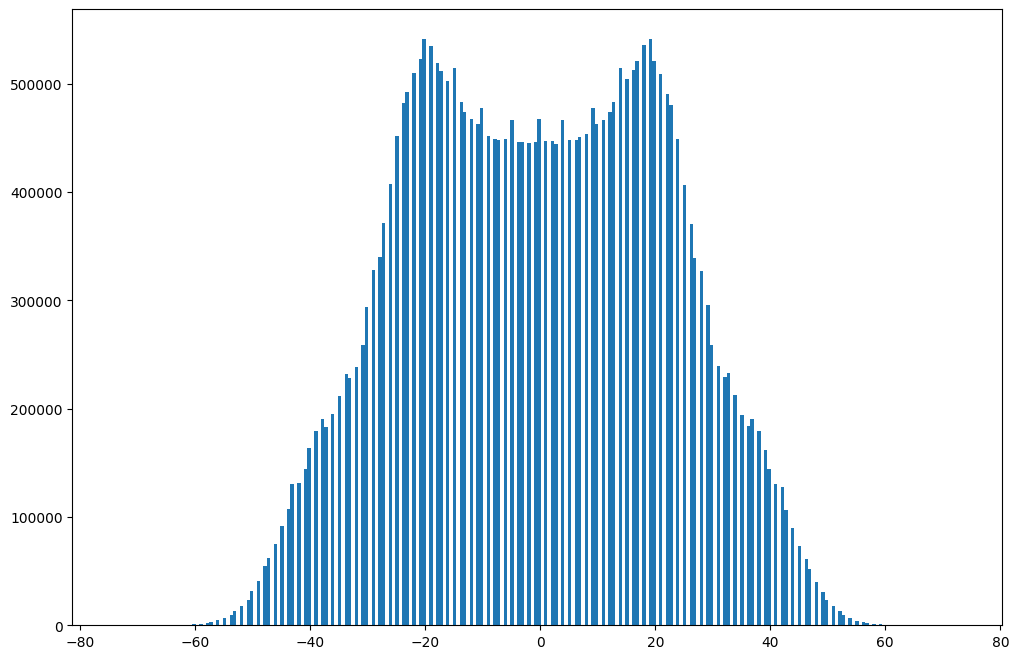

In [23]:
_in="datasets/float_dataset/Post_Processing_RW_Capture_03_09.h5"
_out="datasets/Post_Processing_RW_Capture_03_09_int8.h5"
key="all_IQ"
new_key="all_IQ_8bit"
replace_dataset(_in, _out, key,new_key, quantize)